In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules

os.makedirs("../data/processed", exist_ok=True)
RAW = "../data/raw/data.csv"

In [2]:
df = pd.read_csv(RAW, encoding="ISO-8859-1")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], format="%m/%d/%Y %H:%M")
print(df.shape)
print(df.isna().sum())

(541909, 8)
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [3]:
n_raw = len(df)
df = df.drop_duplicates()
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]      # membuang transaksi yang dibatalkan
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]            # membuang qty/harga tidak valid
non_product = r"^(POST|D|M|DOT|C2|BANK CHARGES|CRUK|S|B|AMAZONFEE|PADS|gift.*)$"
df = df[~df["StockCode"].astype(str).str.match(non_product, case=False)]

df["Description"] = df["Description"].str.strip().str.upper()
df["Revenue"] = (df["Quantity"] * df["UnitPrice"]).round(2)
df["InvoiceDay"] = df["InvoiceDate"].dt.normalize()
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
print(f"Baris: {n_raw:,} -> {len(df):,}")

Baris: 541,909 -> 391,150


              Revenue  Orders     AOV
YearMonth                            
2010-12     565199.56    1394  405.45
2011-01     562682.91     983  572.41
2011-02     442293.59     992  445.86
2011-03     583143.85    1312  444.47
2011-04     454440.88    1139  398.98
2011-05     659242.49    1544  426.97
2011-06     653264.92    1390  469.97
2011-07     591603.79    1321  447.85
2011-08     635514.38    1267  501.59
2011-09     938752.63    1739  539.82
2011-10    1002326.56    1903  526.71
2011-11    1136534.00    2642  430.18
2011-12     512228.08     776  660.09
Country
United Kingdom    0.829
Netherlands       0.032
EIRE              0.029
Germany           0.024
France            0.021
Australia         0.016
Spain             0.006
Switzerland       0.006
Japan             0.004
Belgium           0.004
Name: Revenue, dtype: float64


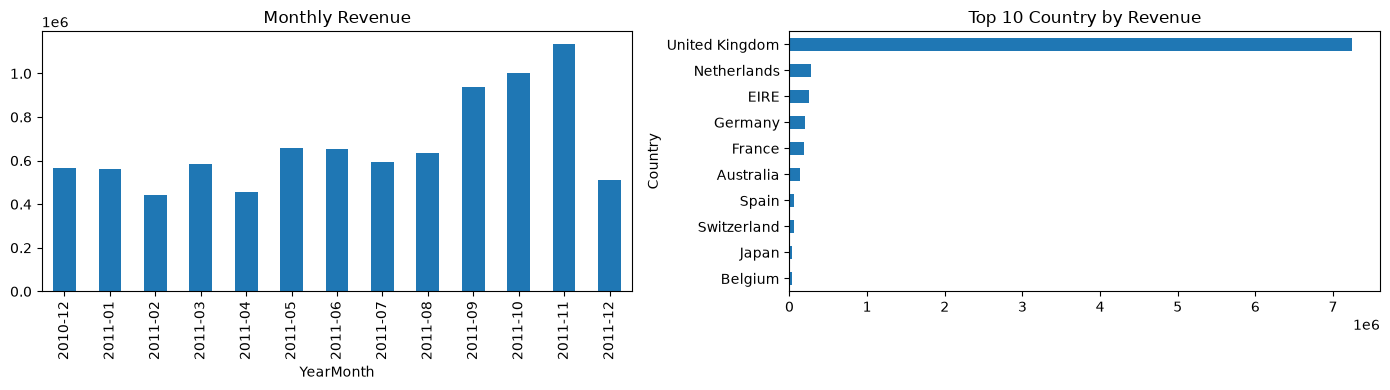

In [4]:
monthly = df.groupby("YearMonth").agg(
    Revenue=("Revenue", "sum"), Orders=("InvoiceNo", "nunique"))
monthly["AOV"] = monthly["Revenue"] / monthly["Orders"]
print(monthly.round(2))

country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
print((country / country.sum()).head(10).round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
monthly["Revenue"].plot(kind="bar", ax=ax[0], title="Monthly Revenue")
country.head(10).plot(kind="barh", ax=ax[1], title="Top 10 Country by Revenue").invert_yaxis()
plt.tight_layout(); plt.show()

In [5]:
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
).reset_index()

feat = ["Recency", "Frequency", "Monetary"]
X = np.log1p(rfm[feat])
for c in feat:                                   # outlier treatment IQR (clipping)
    q1, q3 = X[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    X[c] = X[c].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
Xs = StandardScaler().fit_transform(X)

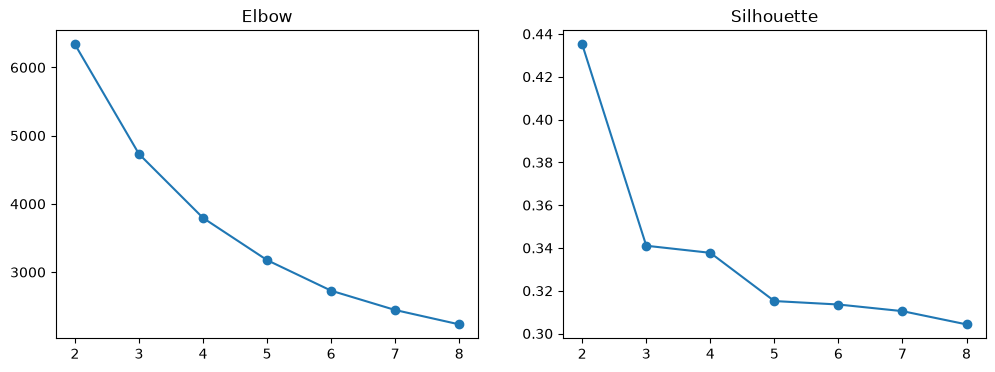

In [6]:
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, km.labels_))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertia, marker="o"); ax[0].set_title("Elbow")
ax[1].plot(ks, sil, marker="o"); ax[1].set_title("Silhouette")
plt.show()

In [ ]:
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(Xs)
rfm["Cluster"] = km.labels_

# skor centroid: recency rendah baik, frequency & monetary tinggi baik
c = km.cluster_centers_
score = -c[:, 0] + c[:, 1] + c[:, 2]
order = np.argsort(score)[::-1]
label_map = {order[0]: "Champions", order[1]: "Loyal", order[2]: "At Risk"}
rfm["Segment"] = rfm["Cluster"].map(label_map)

seg = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum"),
)
seg["CustomerShare"] = seg["Customers"] / seg["Customers"].sum()
seg["RevenueShare"] = seg["TotalRevenue"] / seg["TotalRevenue"].sum()
print(seg.round(3))  

           Customers  Recency  Frequency  Monetary  TotalRevenue  \
Segment                                                            
At Risk         1915  163.750      1.338   353.926     677767.43   
Champions        760   15.938     13.336  7708.786    5858677.72   
Loyal           1659   45.860      3.439  1326.572    2200782.49   

           CustomerShare  RevenueShare  
Segment                                 
At Risk            0.442         0.078  
Champions          0.175         0.671  
Loyal              0.383         0.252  


In [8]:
uk = df[df["Country"] == "United Kingdom"]
top_items = uk["Description"].value_counts().head(150).index
b = uk[uk["Description"].isin(top_items)]
basket = b.groupby(["InvoiceNo", "Description"])["Quantity"].sum().unstack(fill_value=0) > 0

freq = apriori(basket, min_support=0.015, use_colnames=True)
try:
    rules = association_rules(freq, num_itemsets=len(basket), metric="lift", min_threshold=1.2)
except TypeError:
    rules = association_rules(freq, metric="lift", min_threshold=1.2)

rules["antecedents"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules["consequents"] = rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
rules = rules[["antecedents", "consequents", "support", "confidence", "lift"]] \
    .sort_values("lift", ascending=False)
print(rules.head(10))

                                           antecedents  \
286                WOODEN HEART CHRISTMAS SCANDINAVIAN   
287                 WOODEN STAR CHRISTMAS SCANDINAVIAN   
294  PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...   
299                    GREEN REGENCY TEACUP AND SAUCER   
289  GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...   
292                     PINK REGENCY TEACUP AND SAUCER   
298                     PINK REGENCY TEACUP AND SAUCER   
295  GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...   
288  PINK REGENCY TEACUP AND SAUCER, REGENCY CAKEST...   
293                    GREEN REGENCY TEACUP AND SAUCER   

                                           consequents   support  confidence  \
286                 WOODEN STAR CHRISTMAS SCANDINAVIAN  0.021194    0.689655   
287                WOODEN HEART CHRISTMAS SCANDINAVIAN  0.021194    0.748130   
294                    GREEN REGENCY TEACUP AND SAUCER  0.024090    0.890339   
299  PINK REGENCY TEACUP AND SAUCER, ROSE

In [ ]:
cols = ["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate",
        "InvoiceDay", "UnitPrice", "CustomerID", "Country", "Revenue"]
df[cols].to_csv("../data/processed/transactions_clean.csv", index=False, encoding="utf-8-sig")
rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Segment"]] \
    .to_csv("../data/processed/rfm_segments.csv", index=False, encoding="utf-8-sig")
rules.to_csv("../data/processed/basket_rules.csv", index=False, encoding="utf-8-sig")
